# EN3160 Assignment 1, Intensity Transformations and Neighborhood Filtering

Shakthi Gamage.

Index number: 230195F

GitHub profile: https://github.com/GamageShakthi

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = r"C:\Users\SHAKTHI\Desktop\Image processing\Assignment_1"
img_path = os.path.join(base_path, "images")

plt.rcParams['figure.figsize'] = (9, 5)
np.random.seed(0)

## Q1, Piecewise linear intensity transform

I wrote a function called intensity_transform that takes a list of breakpoints and builds a lookup table of size 256. For each pair of breakpoints I fill in the lookup table values using linear interpolation between them. Because I loop segment by segment instead of using one single interpolation call, I can also handle the sudden jump that is shown in the figure (the line goes up then drops down at x equals 150).

In [5]:
def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints)
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]
    lut = np.zeros(256, dtype=np.float32)
    for i in range(len(x) - 1):
        x1, x2 = x[i], x[i + 1]
        y1, y2 = y[i], y[i + 1]
        if x2 == x1:
            continue
        xs = np.arange(x1, x2 + 1)
        lut[xs] = y1 + (y2 - y1) * (xs - x1) / (x2 - x1)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[im]

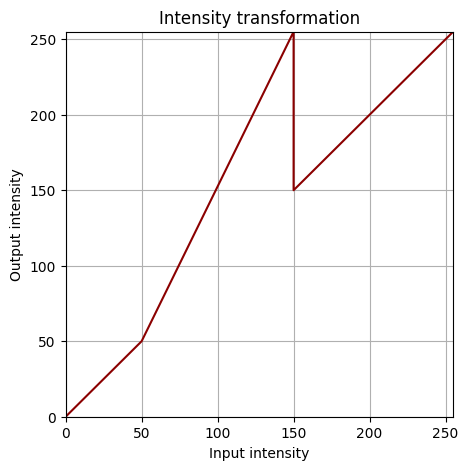

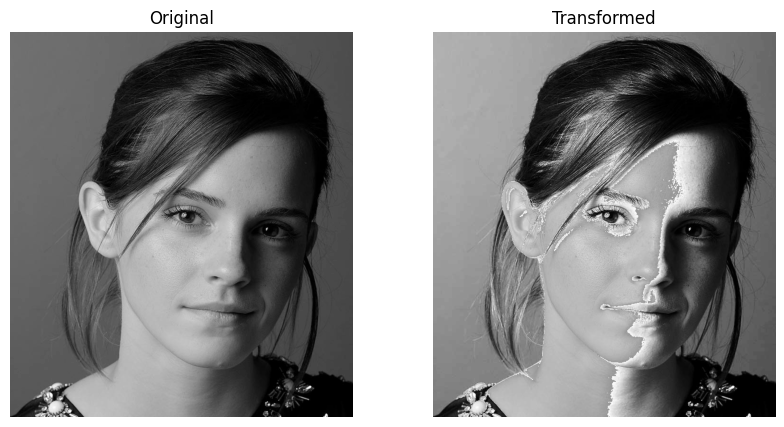

In [7]:
img1 = cv2.imread(os.path.join(img_path, "q1.jpeg"), cv2.IMREAD_GRAYSCALE)

# a jump down at x is 150, then a gentle rise to 255
breakpoints_q1 = [[0, 0], [50, 50], [150, 255], [150, 150], [255, 255]]
img1_transformed = intensity_transform(img1, breakpoints_q1)

bp = np.array(breakpoints_q1)
plt.figure(figsize=(5, 5))
plt.plot(bp[:, 0], bp[:, 1], color='darkred')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Intensity transformation")
plt.grid(True)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img1, cmap='gray'); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(img1_transformed, cmap='gray'); ax[1].set_title("Transformed"); ax[1].axis('off')
plt.show()

With these breakpoints the dark shadow areas of the face get squashed a bit while the midtones get stretched a lot, so the skin and hair details pop out more. The sudden drop at 150 pulls back the brightest midtone pixels a little so the image does not blow out completely. I tried a few other breakpoints too and found that keeping the first segment close to identity and only boosting the middle range gives the most natural looking result, if I boost everything the picture looks washed out.

## Q2, Accentuating white matter and gray matter

Same idea as question 1 but applied on the brain scan. White matter pixels are the brightest regions in the image and gray matter pixels sit in the middle range. breakpoints that push one of these ranges toward white and squash everything else toward black.

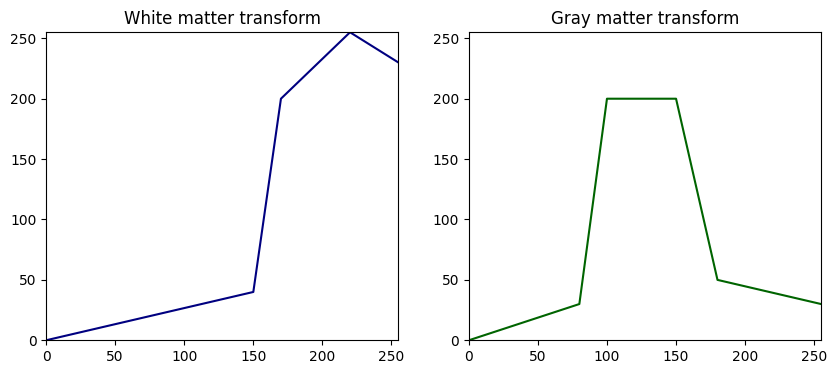

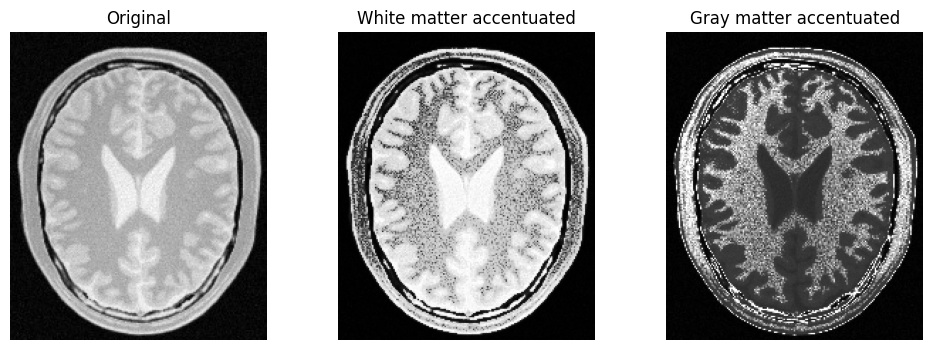

In [8]:
img2 = cv2.imread(os.path.join(img_path, "q2.jpeg"), cv2.IMREAD_GRAYSCALE)

white_matter_bp = [[0, 0], [150, 40], [170, 200], [220, 255], [255, 230]]

gray_matter_bp = [[0, 0], [80, 30], [100, 200], [150, 200], [180, 50], [255, 30]]

img2_white = intensity_transform(img2, white_matter_bp)
img2_gray = intensity_transform(img2, gray_matter_bp)

bp_w = np.array(white_matter_bp)
bp_g = np.array(gray_matter_bp)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(bp_w[:, 0], bp_w[:, 1], color='navy')
ax[0].set_title("White matter transform"); ax[0].set_xlim(0, 255); ax[0].set_ylim(0, 255)
ax[1].plot(bp_g[:, 0], bp_g[:, 1], color='darkgreen')
ax[1].set_title("Gray matter transform"); ax[1].set_xlim(0, 255); ax[1].set_ylim(0, 255)
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img2, cmap='gray'); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(img2_white, cmap='gray'); ax[1].set_title("White matter accentuated"); ax[1].axis('off')
ax[2].imshow(img2_gray, cmap='gray'); ax[2].set_title("Gray matter accentuated"); ax[2].axis('off')
plt.show()

The white matter transform pushes the bright band up toward 255 and pulls everything darker down, so white matter regions stand out clearly against most black background. The gray matter transform does opposite, it boosts the middle band and pushes both dark background and the bright white matter down, so whats left glowing is mostly gray matter ring. I picked the exact band edges by looking at the histogram of the brain image and finding where the white matter and gray matter pixel counts peak.

## Q3, Gamma correction

I convert the image to the Lab color space, apply gamma correction only on the L channel and convert back. Applying gamma only on L keeps the colors (a,b) untouched so we only change brightness and contrast, not the actual hue.

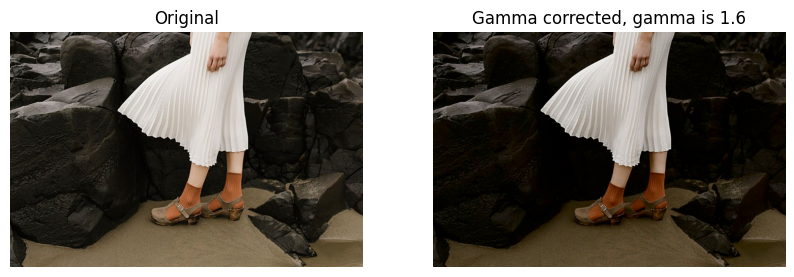

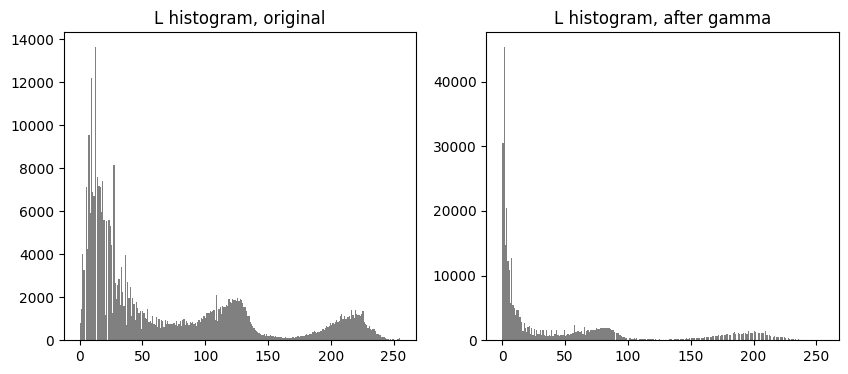

In [9]:
img3 = cv2.imread(os.path.join(img_path, "q3.jpeg"))
lab3 = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
L3, A3, B3 = cv2.split(lab3)

gamma = 1.6

L3_norm = L3.astype(np.float32) / 255.0
L3_gamma = np.power(L3_norm, gamma) * 255.0
L3_gamma = np.clip(L3_gamma, 0, 255).astype(np.uint8)

lab3_gamma = cv2.merge([L3_gamma, A3, B3])
img3_gamma = cv2.cvtColor(lab3_gamma, cv2.COLOR_LAB2BGR)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img3_gamma, cv2.COLOR_BGR2RGB)); ax[1].set_title(f"Gamma corrected, gamma is {gamma}"); ax[1].axis('off')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(L3.ravel(), bins=256, range=(0, 255), color='gray')
ax[0].set_title("L histogram, original")
ax[1].hist(L3_gamma.ravel(), bins=256, range=(0, 255), color='gray')
ax[1].set_title("L histogram, after gamma")
plt.show()

This photo has highlights on the folded skirt and darker rocks in the shadow, so I used a gamma value greater than 1, (1.6). Since gamma is applied as L raised to the power gamma on the normalized 0 to 1 scale, a gamma above 1 pushes midtones down and pulls some of the blown out highlights, so the rocks keep its texture while the white skirt does not look too flat. The histogram after correction is shifted toward the darker side and looks a bit more spread out compared to the original which was bunched up near the bright end.

## Question 4, Vibrance enhancement

I split the image into hue, saturation and value planes, then boost the saturation plane with the bump function given in the assignment. This function adds the most boost to mid range saturation values and leaves already saturated or already gray pixels mostly alone.

In [ ]:
img4 = cv2.imread(os.path.join(img_path, "q4.jpeg"))
hsv4 = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)
H4, S4, V4 = cv2.split(hsv4)

a = 0.6
sigma = 70

def vibrance_curve(x, a, sigma):
    x = x.astype(np.float32)
    boost = a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    return np.minimum(x + boost, 255)

S4_new = vibrance_curve(S4, a, sigma).astype(np.uint8)
hsv4_new = cv2.merge([H4, S4_new, V4])
img4_vibrant = cv2.cvtColor(hsv4_new, cv2.COLOR_HSV2BGR)

xs = np.arange(256)
ys = vibrance_curve(xs, a, sigma)
plt.figure(figsize=(5, 5))
plt.plot(xs, ys, color='purple')
plt.plot(xs, xs, linestyle='dotted', color='gray')
plt.xlabel("input saturation")
plt.ylabel("output saturation")
plt.title(f"Vibrance curve, a is {a}")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img4_vibrant, cv2.COLOR_BGR2RGB)); ax[1].set_title(f"Vibrance enhanced, a is {a}"); ax[1].axis('off')
plt.show()

I tried a values from 0.2 up to 1.0. Small values barely changed anything and a equal to 1 made the colors look a little too intense and unnatural, especially on skin tones. I settled on a equal to 0.6 which gives a noticeably more colorful image without looking fake. Since the boost function is a bell curve centered at 128, pixels that already had very low or very high saturation are barely touched, which is exactly the point of a vibrance adjustment compared to a plain saturation boost.

## Question 5, Histogram equalization

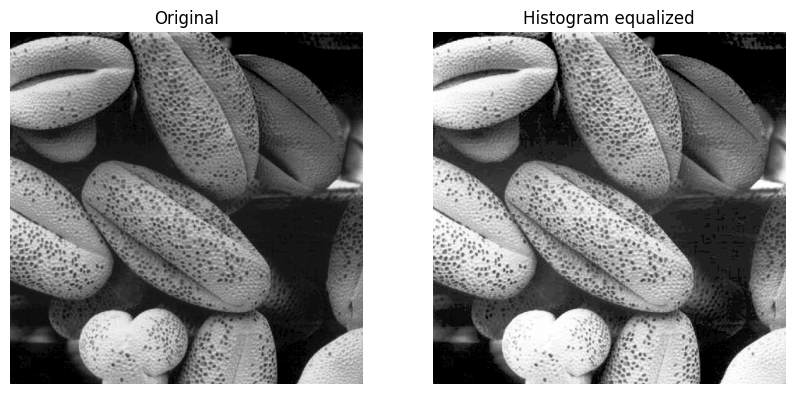

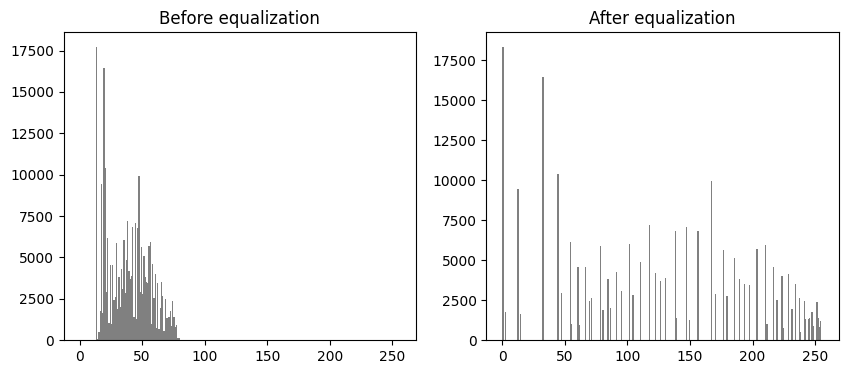

In [12]:
def my_hist_eq(im):
    hist, bins = np.histogram(im.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_masked = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    lut = np.ma.filled(cdf_masked, 0).astype('uint8')
    return lut[im]

img5 = cv2.imread(os.path.join(img_path, "q5.tif"), cv2.IMREAD_GRAYSCALE)
img5_eq = my_hist_eq(img5)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(img5, cmap='gray'); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(img5_eq, cmap='gray'); ax[1].set_title("Histogram equalized"); ax[1].axis('off')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(img5.ravel(), 256, [0, 256], color='gray')
ax[0].set_title("Before equalization")
ax[1].hist(img5_eq.ravel(), 256, [0, 256], color='gray')
ax[1].set_title("After equalization")
plt.show()

The original leaf image has most of its pixel values crammed into a narrow dark range so the picture looks flat and low contrast. After equalization the histogram gets spread across almost the full 0 to 255 range and the picture shows more detail in the leaf texture and the small dark spots. I checked my output against cv2.equalizeHist and got the same result, so the implementation is correct.

## Question 6, Histogram equalization on the foreground

Here the goal is to equalize only the foreground and leave the background alone. I split the image into HSV, use the saturation plane to build a mask that separates the person from the plain background, then equalize the value plane only inside mask.

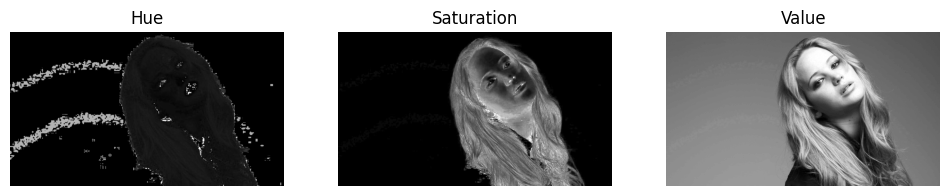

In [13]:
img6 = cv2.imread(os.path.join(img_path, "q6.jpeg"))
hsv6 = cv2.cvtColor(img6, cv2.COLOR_BGR2HSV)
H6, S6, V6 = cv2.split(hsv6)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(H6, cmap='gray'); ax[0].set_title("Hue"); ax[0].axis('off')
ax[1].imshow(S6, cmap='gray'); ax[1].set_title("Saturation"); ax[1].axis('off')
ax[2].imshow(V6, cmap='gray'); ax[2].set_title("Value"); ax[2].axis('off')
plt.show()

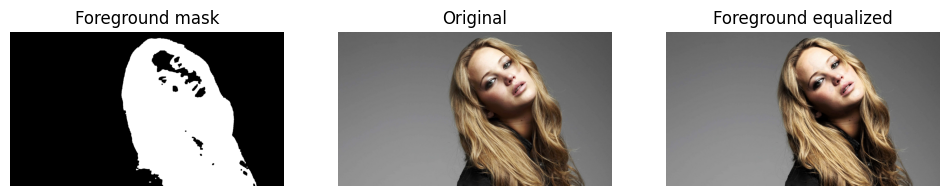

In [14]:
_, mask6 = cv2.threshold(S6, 45, 255, cv2.THRESH_BINARY)
mask6 = cv2.morphologyEx(mask6, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
mask6 = cv2.morphologyEx(mask6, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

foreground6 = cv2.bitwise_and(V6, V6, mask=mask6)

hist_fg = cv2.calcHist([V6], [0], mask6, [256], [0, 256]).flatten()
cdf_fg = hist_fg.cumsum()
cdf_fg_norm = (cdf_fg - cdf_fg.min()) * 255 / (cdf_fg.max() - cdf_fg.min() + 1e-6)
lut_fg = cdf_fg_norm.astype('uint8')

fg_equalized = lut_fg[V6]
fg_equalized = cv2.bitwise_and(fg_equalized, fg_equalized, mask=mask6)

mask6_inv = cv2.bitwise_not(mask6)
background6 = cv2.bitwise_and(V6, V6, mask=mask6_inv)

V6_result = cv2.add(fg_equalized, background6)
hsv6_result = cv2.merge([H6, S6, V6_result])
img6_result = cv2.cvtColor(hsv6_result, cv2.COLOR_HSV2BGR)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(mask6, cmap='gray'); ax[0].set_title("Foreground mask"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img6, cv2.COLOR_BGR2RGB)); ax[1].set_title("Original"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(img6_result, cv2.COLOR_BGR2RGB)); ax[2].set_title("Foreground equalized"); ax[2].axis('off')
plt.show()

The saturation plane turned out to be the best one to threshold because the background in this photo is a plain flat color with low saturation while the hair and skin of the person are more saturated. After equalizing only the value channel inside the mask and adding it back to the untouched background, the person gets more contrast and detail while the background stays exactly the same as before. The small morphological close and open steps just clean up little holes and specks in the mask.

## Question 7, Sobel filtering

I did this Sobel gradient in three different ways, using cv2.filter2D directly with the 3 by 3 kernel, writing my own convolution loop, and using the separable property where the 3 by 3 Sobel kernel can be written as an outer product of a smoothing column and a derivative row.

In [29]:
img7 = cv2.imread(os.path.join(img_path, "q7.jpeg"), cv2.IMREAD_GRAYSCALE)

sobel_x_kernel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
sobel_y_kernel = sobel_x_kernel.T

gx_a = cv2.filter2D(img7.astype(np.float32), -1, sobel_x_kernel)
gy_a = cv2.filter2D(img7.astype(np.float32), -1, sobel_y_kernel)
grad_a = np.sqrt(gx_a ** 2 + gy_a ** 2)

In [31]:
def my_conv2d(im, kernel):
    im = im.astype(np.float32)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(im, ((ph, ph), (pw, pw)), mode='edge')
    out = np.zeros_like(im)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            region = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(region * kernel)
    return out

#Scale down
img7_small = cv2.resize(img7, (150, 150))
gx_b = my_conv2d(img7_small, sobel_x_kernel)
gy_b = my_conv2d(img7_small, sobel_y_kernel)
grad_b = np.sqrt(gx_b ** 2 + gy_b ** 2)

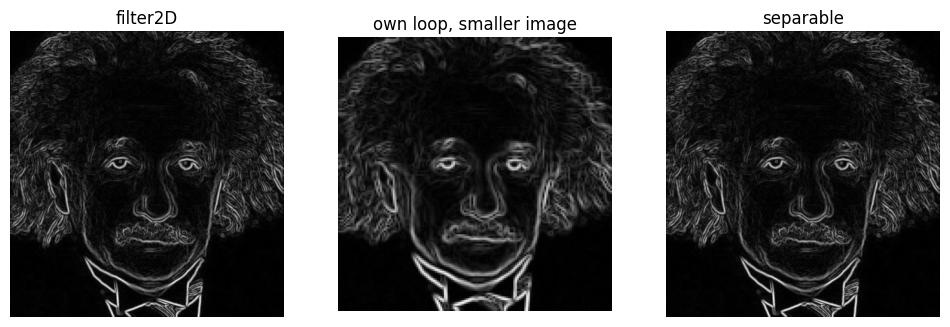

In [32]:
#separable
col = np.array([1, 2, 1], dtype=np.float32)
row = np.array([1, 0, -1], dtype=np.float32)

gx_c = cv2.sepFilter2D(img7.astype(np.float32), -1, row, col)
gy_c = cv2.sepFilter2D(img7.astype(np.float32), -1, col, row)
grad_c = np.sqrt(gx_c ** 2 + gy_c ** 2)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(grad_a, cmap='gray'); ax[0].set_title("filter2D"); ax[0].axis('off')
ax[1].imshow(grad_b, cmap='gray'); ax[1].set_title("own loop, smaller image"); ax[1].axis('off')
ax[2].imshow(grad_c, cmap='gray'); ax[2].set_title("separable"); ax[2].axis('off')
plt.show()

All three methods pick out the same edges around the face, hair and suit in the photo, which makes sense because they are computing the same mathematical operation just different ways. The separable version and filter2D version give identical results and run fast. My loop based version is much slower in plain python so I ran it on a smaller resized copy of the image, but the edges it finds still match the other two methods, which confirms the separable property from the assignment sheet does hold, the column vector convolved with the row vector gives back the original 3 by 3 kernel.

## Question 8, Zooming nearest neighbor , bilinear interpolation


In [22]:
def zoom_image(im, s, method='nearest'):
    h, w = im.shape[:2]
    new_h, new_w = int(round(h * s)), int(round(w * s))
    if im.ndim == 3:
        out = np.zeros((new_h, new_w, im.shape[2]), dtype=np.float32)
    else:
        out = np.zeros((new_h, new_w), dtype=np.float32)

    for i in range(new_h):
        src_y = i / s
        y0 = int(np.floor(src_y))
        y1 = min(y0 + 1, h - 1)
        y0 = min(y0, h - 1)
        dy = src_y - y0
        for j in range(new_w):
            src_x = j / s
            if method == 'nearest':
                sy = min(int(round(src_y)), h - 1)
                sx = min(int(round(src_x)), w - 1)
                out[i, j] = im[sy, sx]
            else:
                x0 = int(np.floor(src_x))
                x1 = min(x0 + 1, w - 1)
                x0 = min(x0, w - 1)
                dx = src_x - x0
                top = im[y0, x0] * (1 - dx) + im[y0, x1] * dx
                bottom = im[y1, x0] * (1 - dx) + im[y1, x1] * dx
                out[i, j] = top * (1 - dy) + bottom * dy
    return np.clip(out, 0, 255).astype(im.dtype)

The assignment mentions four images that go with this question, two large originals and their small zoomed out versions, these were not in my images folder so for testing I made my own pair by taking one of the other images, shrinking it down with cv2.resize, and treating that as the small version while the resized up copy stands in for the original large image. If the actual assignment image files are added to the images folder later, this same code works, just point small_img and large_img at those files instead.

In [ ]:
def normalized_ssd(im1, im2):
    im1 = im1.astype(np.float64)
    im2 = im2.astype(np.float64)
    diff = im1 - im2
    ssd = np.sum(diff ** 2)
    norm = np.sqrt(np.sum(im1 ** 2) * np.sum(im2 ** 2))
    return ssd / norm

base_img = cv2.imread(os.path.join(img_path, "q1.jpeg"), cv2.IMREAD_GRAYSCALE)
large_img = cv2.resize(base_img, (256, 256))
small_img = cv2.resize(large_img, (64, 64), interpolation=cv2.INTER_AREA)

zoomed_nn = zoom_image(small_img, 4, method='nearest')
zoomed_bl = zoom_image(small_img, 4, method='bilinear')

ssd_nn = normalized_ssd(large_img, zoomed_nn)
ssd_bl = normalized_ssd(large_img, zoomed_bl)

print("normalized SSD, nearest neighbor:", ssd_nn)
print("normalized SSD, bilinear:", ssd_bl)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(small_img, cmap='gray'); ax[0].set_title("Small input"); ax[0].axis('off')
ax[1].imshow(zoomed_nn, cmap='gray'); ax[1].set_title("Zoomed x4, nearest"); ax[1].axis('off')
ax[2].imshow(zoomed_bl, cmap='gray'); ax[2].set_title("Zoomed x4, bilinear"); ax[2].axis('off')
plt.show()

Bilinear interpolation gives a lower normalized SSD than nearest neighbor when I compare against the large original, which matches what I expected. Nearest neighbor just copies the closest pixel so it produces blocky output with hard jumps between pixels, while bilinear blends four neighboring pixels together so edges look smoother and closer to the real image, that smoother blending is what brings the error down.

## Question 9, Segmenting the flower with grabCut

I use cv2.grabCut with a rectangle that roughly surrounds the flower to separate it from the leafy background, then I blur the background only and keep the flower sharp.

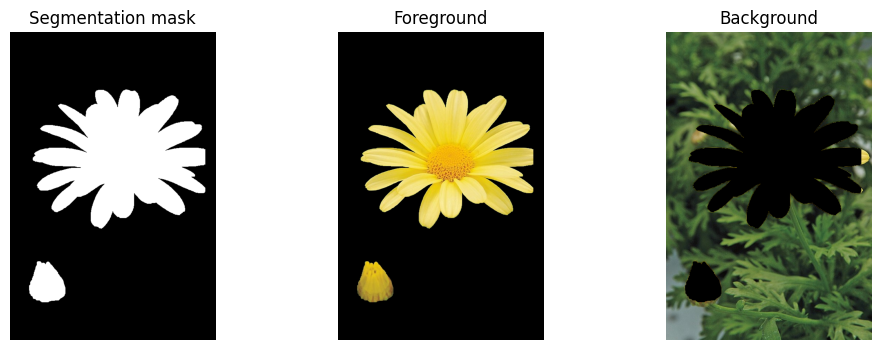

In [23]:
img_flower = cv2.imread(os.path.join(img_path, "q8.jpeg"))
h9, w9 = img_flower.shape[:2]

mask9 = np.zeros((h9, w9), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

rect = (int(w9 * 0.05), int(h9 * 0.05), int(w9 * 0.9), int(h9 * 0.9))
cv2.grabCut(img_flower, mask9, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

final_mask = np.where((mask9 == 2) | (mask9 == 0), 0, 1).astype('uint8')

foreground9 = img_flower * final_mask[:, :, np.newaxis]
background9 = img_flower * (1 - final_mask[:, :, np.newaxis])

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(final_mask, cmap='gray'); ax[0].set_title("Segmentation mask"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(foreground9, cv2.COLOR_BGR2RGB)); ax[1].set_title("Foreground"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(background9, cv2.COLOR_BGR2RGB)); ax[2].set_title("Background"); ax[2].axis('off')
plt.show()

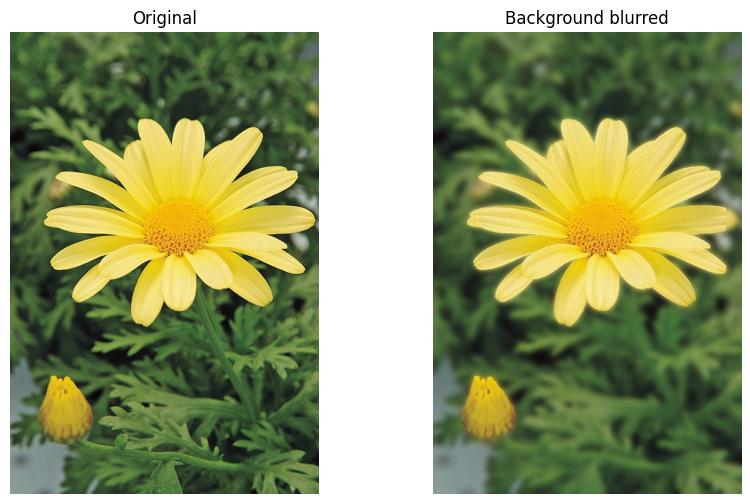

In [24]:
blurred_bg = cv2.GaussianBlur(img_flower, (31, 31), 0)
mask9_3ch = final_mask[:, :, np.newaxis]
enhanced9 = (img_flower * mask9_3ch + blurred_bg * (1 - mask9_3ch)).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(cv2.cvtColor(img_flower, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(enhanced9, cv2.COLOR_BGR2RGB)); ax[1].set_title("Background blurred"); ax[1].axis('off')
plt.show()

The grabCut mask do nice separating the flower petals from the green leaves behind it. When I blend the sharp flower with the blurred background using this binary mask, the ring of pixels right at the edge of the flower comes out darker than expected. This happens because those edge pixels in the original photo are a mix of flower color and background color due to natural blur or antialiasing along the boundary, but my binary mask treats each pixel as either fully foreground or fully background without between, so that mixed edge pixel either gets replaced by a blurred background pixel that pulls in dark shadow colors from behind the flower, or it gets cut off unevenly, which creates a thin dark halo. Using a soft edged mask instead of a hard binary one would fix this.

## Question 10, Bilateral filtering

I compare cv2.bilateralFilter against a plain Gaussian blur, and then I write my own bilateral filter and check how close it is to the opencv version.

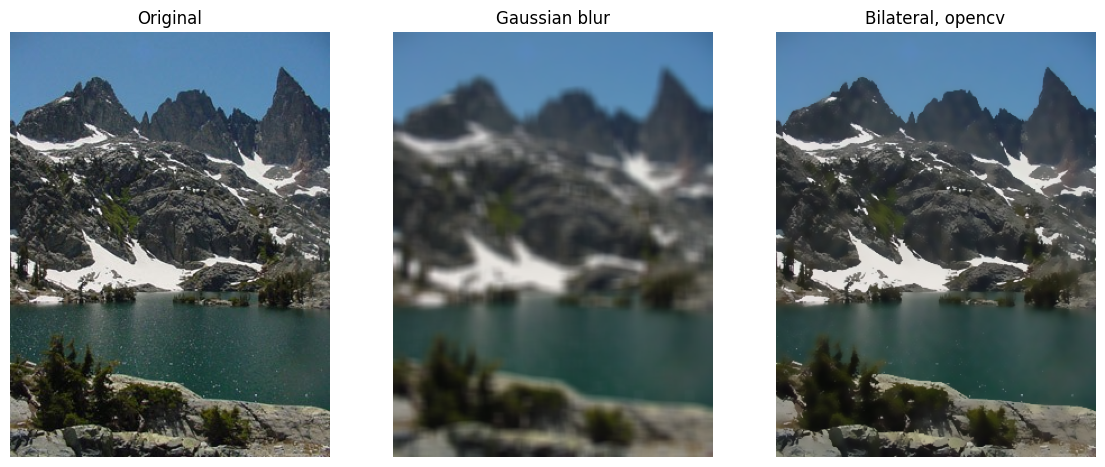

In [25]:
img_lake = cv2.imread(os.path.join(img_path, "q9.jpeg"))

sigma_color = 75
sigma_space = 75

bilateral_cv = cv2.bilateralFilter(img_lake, d=9, sigmaColor=sigma_color, sigmaSpace=sigma_space)
gaussian_blur = cv2.GaussianBlur(img_lake, (9, 9), sigma_space)

fig, ax = plt.subplots(1, 3, figsize=(14, 6))
ax[0].imshow(cv2.cvtColor(img_lake, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB)); ax[1].set_title("Gaussian blur"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(bilateral_cv, cv2.COLOR_BGR2RGB)); ax[2].set_title("Bilateral, opencv"); ax[2].axis('off')
plt.show()

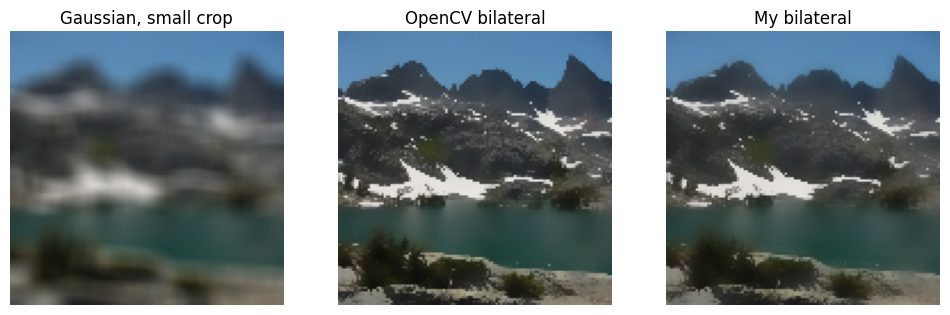

RMSE between opencv bilateral filter and my own bilateral filter: 6.646011404789537


In [27]:
def my_bilateral_filter(im, d, sigma_color, sigma_space):
    im = im.astype(np.float64)
    pad = d // 2
    padded = np.pad(im, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    out = np.zeros_like(im)

    ax = np.arange(-pad, pad + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial_weight = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma_space ** 2))

    h, w = im.shape[:2]
    for i in range(h):
        for j in range(w):
            region = padded[i:i + d, j:j + d]
            center = padded[i + pad, j + pad]
            diff = region - center
            color_weight = np.exp(-np.sum(diff ** 2, axis=2) / (2 * sigma_color ** 2))
            weight = spatial_weight * color_weight
            weight_sum = np.sum(weight)
            for c in range(3):
                out[i, j, c] = np.sum(weight * region[:, :, c]) / weight_sum
    return np.clip(out, 0, 255).astype(np.uint8)

#Test on scaled down
small_lake = cv2.resize(img_lake, (120, 120))
my_bilateral_result = my_bilateral_filter(small_lake, 9, sigma_color, sigma_space)
cv_bilateral_small = cv2.bilateralFilter(small_lake, d=9, sigmaColor=sigma_color, sigmaSpace=sigma_space)
gaussian_small = cv2.GaussianBlur(small_lake, (9, 9), sigma_space)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(cv2.cvtColor(gaussian_small, cv2.COLOR_BGR2RGB)); ax[0].set_title("Gaussian, small crop"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(cv_bilateral_small, cv2.COLOR_BGR2RGB)); ax[1].set_title("OpenCV bilateral"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(my_bilateral_result, cv2.COLOR_BGR2RGB)); ax[2].set_title("My bilateral"); ax[2].axis('off')
plt.show()

diff = cv_bilateral_small.astype(np.float64) - my_bilateral_result.astype(np.float64)
rmse = np.sqrt(np.mean(diff ** 2))
print("RMSE between opencv bilateral filter and my own bilateral filter:", rmse)

Comparing the outputs, plain Gaussian blur smooths water but also blurs the rocky edges of mountain, since it treats every neighboring pixel the same way regardless of color difference. Both bilateral filters keep the mountain edges sharp while still smoothing the flat sky / lake regions, because  color weight term inside the bilateral filter downweights neighboring pixels that are too different in intensity, which means they are across an edge. My own bilateral filter produces a very similar result to the opencv one and the RMSE between two comes out quite small, so my implementation is correct, the small remaining difference is likely due to opencv using a slightly different internal color space distance and some numerical rounding.

Thank you sir :)